# Compare HP k15-k20 vs TEA for Family, Superfamily, and Fold

This notebook compares HP (hydrophobic-polar) encoding across different ksizes (k=15 to k=20) against TEA baseline for SCOPE40 hierarchical levels.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

sns.set_style("whitegrid")
%matplotlib inline

## Load HP results

In [2]:
# Path to HP results (CSV files)
hp_results_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")

# List all HP CSV files
hp_files = sorted(hp_results_dir.glob("*hp*.csv"))
print(f"Found {len(hp_files)} HP CSV files")
for f in hp_files[:10]:
    file_size_gb = f.stat().st_size / (1024**3)
    print(f"  {f.name} ({file_size_gb:.2f} GB)")

Found 6 HP CSV files
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k15.scaled1.kmerseek.results.csv (57.88 GB)
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k16.scaled1.kmerseek.results.csv (28.87 GB)
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k17.scaled1.kmerseek.results.csv (14.43 GB)
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k18.scaled1.kmerseek.results.csv (7.23 GB)
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k19.scaled1.kmerseek.results.csv (3.62 GB)
  astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results.csv (1.82 GB)


In [3]:
# Load all HP results and concatenate
# For files larger than 8GB, read only first 15M rows
hp_dfs = []

MAX_ROWS = 15_000_000
SIZE_THRESHOLD_GB = 8

for hp_file in hp_files:
    file_size_gb = hp_file.stat().st_size / (1024**3)

    # Extract ksize from filename (e.g., 'hp.k15' -> 15)
    filename = hp_file.stem
    if ".k" in filename:
        ksize = int(filename.split(".k")[1].split(".")[0])
    else:
        print(f"Warning: Could not extract ksize from {filename}")
        continue

    print(f"Loading {filename} (k={ksize}, {file_size_gb:.2f} GB)...", end=" ")

    # Read CSV with row limit for large files
    if file_size_gb > SIZE_THRESHOLD_GB:
        print(f"Reading first {MAX_ROWS:,} rows...")
        df = pl.read_csv(hp_file, n_rows=MAX_ROWS)
    else:
        print("Reading all rows...")
        df = pl.read_csv(hp_file)

    df = df.with_columns(pl.lit(ksize).alias("ksize"))
    hp_dfs.append(df)
    print(f"  Loaded {df.shape[0]:,} rows")

hp_data = pl.concat(hp_dfs)
print(f"\nCombined HP data shape: {hp_data.shape}")
print(f"Ksizes found: {sorted(hp_data['ksize'].unique().to_list())}")
hp_data.head()

Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k15.scaled1.kmerseek.results (k=15, 57.88 GB)... Reading first 15,000,000 rows...
  Loaded 15,000,000 rows
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k16.scaled1.kmerseek.results (k=16, 28.87 GB)... Reading first 15,000,000 rows...
  Loaded 15,000,000 rows
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k17.scaled1.kmerseek.results (k=17, 14.43 GB)... Reading first 15,000,000 rows...
  Loaded 15,000,000 rows
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k18.scaled1.kmerseek.results (k=18, 7.23 GB)... Reading all rows...
  Loaded 14,306,424 rows
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k19.scaled1.kmerseek.results (k=19, 3.62 GB)... Reading all rows...
  Loaded 7,134,549 rows
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k20.scaled1.kmerseek.results (k=20, 1.82 GB)... Reading all rows...
  Loaded 3,563,401 rows

Combined HP data shape: (70004374, 30)
Ksizes f

query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,f64,i64,i32,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""defd3ad60ebdb035""","""d1woua_ c.47.1.16 (A:) Putativ…","""8564a648c2dad683""",1.0,6,15,1,"""hp""",0.057143,1.0,1.0,1.0,0.0,0.057143,17.5,31.489082,0.005326,2.1109e-14,2.1109e-14,0.031956,187.756701,0,20,"""LSRLERVYQSEQAEKLLLAG""",8,28,"""FEEFHRAVEQHNGKTIFAYF""","""hpphpphhpppphpphhhhh""",20
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""defd3ad60ebdb035""","""d3t6ec_ a.138.1.2 (C:) Photosy…","""37f835b1f76c14eb""",1.0,6,15,1,"""hp""",0.01875,1.0,1.0,1.0,0.0,0.01875,53.333333,31.489082,0.005326,2.1109e-14,2.1109e-14,0.031956,187.756701,0,20,"""LSRLERVYQSEQAEKLLLAG""",249,269,"""AQTFESWGKKSTPQRAIAWW""","""hpphpphhpppphpphhhhh""",20
"""d1y8xb1 c.111.1.2 (B:349-440) …","""c0e0c704e0e89a1e""","""d1ngvb_ c.111.1.2 (B:) automat…","""a54b5110dae3ad5c""",1.0,78,15,1,"""hp""",0.1875,1.0,1.0,1.0,0.0,0.1875,5.333333,410.621549,0.0054,4.6701e-179,0.0,0.421229,185.17222,0,92,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…",337,429,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…","""hhpphphphphphpphhphhppphphphpp…",92
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",130,145,"""GGIFLGAMGGAIFAY""","""hhhhhhhhhhhhhhh""",15
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",131,146,"""GIFLGAMGGAIFAYL""","""hhhhhhhhhhhhhhh""",15


## Examine data structure and calculate sensitivity

In [4]:
# No need to filter for ksize - files are already ksize-specific
# Just use the hp_data directly
hp_filtered = hp_data

print(f"HP data shape: {hp_filtered.shape}")
print(f"Ksizes: {sorted(hp_filtered['ksize'].unique().to_list())}")

# Check available columns
print(f"\nColumns: {hp_filtered.columns}")

HP data shape: (70004374, 30)
Ksizes: [15, 16, 17, 18, 19, 20]

Columns: ['query_name', 'query_md5', 'target_name', 'target_md5', 'containment', 'n_intersecting_hashes', 'ksize', 'scaled', 'moltype', 'jaccard', 'max_containment', 'average_abund', 'median_abund', 'std_abund', 'containment_target_in_query', 'f_weighted_target_in_query', 'tfidf', 'average_kmer_frequency', 'prob_random_cooccurrence', 'prob_random_cooccurrence_symmetric', 'expected_intersecting_hashes', 'observed_over_expected', 'query_start', 'query_end', 'query_subseq', 'target_start', 'target_end', 'target_subseq', 'moltype_seq', 'region_length']


In [5]:
# Extract hierarchical levels from SCOPE names
# SCOPE format: d[SCOP_ID].[family].[superfamily].[fold].[class]
# Example: d1a0a_.1.1.1.1


def extract_scope_levels(name):
    """Extract SCOPE hierarchical levels from name."""
    # SCOPE names typically look like: d1a0a_.1.1.1.1 or similar
    # The numbers after the ID represent: family.superfamily.fold.class
    parts = name.split(".")
    if len(parts) >= 4:
        # Last 4 parts are family, superfamily, fold, class
        return {
            "family": parts[-4],
            "superfamily": parts[-3],
            "fold": parts[-2],
            "class": parts[-1],
        }
    return None


def add_hierarchical_levels(df):
    """Add hierarchical level columns to the dataframe."""
    # Extract query levels
    query_levels = (
        df["query_name"]
        .map_elements(extract_scope_levels, return_dtype=pl.Struct)
        .alias("query_levels")
    )

    # Extract target levels
    target_levels = (
        df["target_name"]
        .map_elements(extract_scope_levels, return_dtype=pl.Struct)
        .alias("target_levels")
    )

    # Add columns
    df = df.with_columns(
        [
            query_levels.struct.field("family").alias("query_family"),
            query_levels.struct.field("superfamily").alias("query_superfamily"),
            query_levels.struct.field("fold").alias("query_fold"),
            target_levels.struct.field("family").alias("target_family"),
            target_levels.struct.field("superfamily").alias("target_superfamily"),
            target_levels.struct.field("fold").alias("target_fold"),
        ]
    )

    # Add match indicators
    df = df.with_columns(
        [
            (pl.col("query_family") == pl.col("target_family")).alias("family_match"),
            (pl.col("query_superfamily") == pl.col("target_superfamily")).alias(
                "superfamily_match"
            ),
            (pl.col("query_fold") == pl.col("target_fold")).alias("fold_match"),
        ]
    )

    return df


# Add hierarchical levels to HP data
print("Adding hierarchical levels to HP data...")
hp_filtered = add_hierarchical_levels(hp_filtered)
print(f"HP data shape after adding levels: {hp_filtered.shape}")
hp_filtered.head(10)

Adding hierarchical levels to HP data...
HP data shape after adding levels: (70004374, 39)


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,query_family,query_superfamily,query_fold,target_family,target_superfamily,target_fold,family_match,superfamily_match,fold_match
str,str,str,str,f64,i64,i32,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64,str,str,str,str,str,str,bool,bool,bool
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""defd3ad60ebdb035""","""d1woua_ c.47.1.16 (A:) Putativ…","""8564a648c2dad683""",1.0,6,15,1,"""hp""",0.057143,1.0,1.0,1.0,0.0,0.057143,17.5,31.489082,0.005326,2.1109e-14,2.1109e-14,0.031956,187.756701,0,20,"""LSRLERVYQSEQAEKLLLAG""",8,28,"""FEEFHRAVEQHNGKTIFAYF""","""hpphpphhpppphpphhhhh""",20,"""d4aa7a1 c""","""68""","""1""","""d1woua_ c""","""47""","""1""",false,false,true
"""d4aa7a1 c.68.1.0 (A:232-251) a…","""defd3ad60ebdb035""","""d3t6ec_ a.138.1.2 (C:) Photosy…","""37f835b1f76c14eb""",1.0,6,15,1,"""hp""",0.01875,1.0,1.0,1.0,0.0,0.01875,53.333333,31.489082,0.005326,2.1109e-14,2.1109e-14,0.031956,187.756701,0,20,"""LSRLERVYQSEQAEKLLLAG""",249,269,"""AQTFESWGKKSTPQRAIAWW""","""hpphpphhpppphpphhhhh""",20,"""d4aa7a1 c""","""68""","""1""","""d3t6ec_ a""","""138""","""1""",false,false,true
"""d1y8xb1 c.111.1.2 (B:349-440) …","""c0e0c704e0e89a1e""","""d1ngvb_ c.111.1.2 (B:) automat…","""a54b5110dae3ad5c""",1.0,78,15,1,"""hp""",0.1875,1.0,1.0,1.0,0.0,0.1875,5.333333,410.621549,0.0054,4.6701e-179,0.0,0.421229,185.17222,0,92,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…",337,429,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…","""hhpphphphphphpphhphhppphphphpp…",92,"""d1y8xb1 c""","""111""","""1""","""d1ngvb_ c""","""111""","""1""",false,true,true
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",130,145,"""GGIFLGAMGGAIFAY""","""hhhhhhhhhhhhhhh""",15,"""d4pv1e_ f""","""23""","""24""","""d7lx0l_ f""","""31""","""1""",false,false,false
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",131,146,"""GIFLGAMGGAIFAYL""","""hhhhhhhhhhhhhhh""",15,"""d4pv1e_ f""","""23""","""24""","""d7lx0l_ f""","""31""","""1""",false,false,false
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",132,147,"""IFLGAMGGAIFAYLL""","""hhhhhhhhhhhhhhh""",15,"""d4pv1e_ f""","""23""","""24""","""d7lx0l_ f""","""31""","""1""",false,false,false
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,0,15,"""ILGAVFYIVFIALFF""",133,148,"""FLGAMGGAIFAYLLL""","""hhhhhhhhhhhhhhh""",15,"""d4pv1e_ f""","""23""","""24""","""d7lx0l_ f""","""31""","""1""",false,false,false
"""d4pv1e_ f.23.24.1 (E:) PetL su…","""7b33e1717fa04c23""","""d7lx0l_ f.31.1.0 (L:) automate…","""f48a74e0a35052e0""",1.0,4,15,1,"""hp""",0.027397,1.0,2.625,1.0,2.814583,0.027397,10.642857,17.875788,0.011564,1.7244e-8,1.7244e-8,0.046254,86.478632,1,16,"""LGAVFYIVFIALFFG""",130,145,"""GGIFLGAMGGAIFAY""","""hhhhhhhhhhhhhhh"""

In [ ]:
# Calculate sensitivity until first false positive
# For each query, rank targets by a metric, and find when the first FP occurs


def calculate_sensitivity_to_first_fp(df, metric_col, level_match_col, has_ksize=True):
    """
    Calculate sensitivity until first false positive.

    For each query, targets are ranked by metric_col (descending).
    We count how many TPs are found before the first FP.

    Parameters:
    -----------
    df : polars.DataFrame
        Data with metric and match columns
    metric_col : str
        Column to rank by (e.g., 'tfidf', 'jaccard', 'max_containment')
    level_match_col : str
        Column indicating TP/FP (e.g., 'family_match', 'superfamily_match', 'fold_match')
    has_ksize : bool
        Whether to group by ksize

    Returns:
    --------
    polars.DataFrame with sensitivity results
    """
    results = []

    if has_ksize:
        group_cols = ["ksize", "query_name"]
    else:
        group_cols = ["query_name"]

    # Group by query (and ksize if applicable)
    for group_key in df.select(group_cols).unique().iter_rows():
        if has_ksize:
            ksize, query_name = group_key
            query_df = df.filter(
                (pl.col("ksize") == ksize) & (pl.col("query_name") == query_name)
            )
        else:
            query_name = group_key[0]
            query_df = df.filter(pl.col("query_name") == query_name)
            ksize = None

        # Sort by metric (descending - higher is better)
        query_df = query_df.sort(metric_col, descending=True)

        # Count TPs before first FP
        matches = query_df[level_match_col].to_list()

        # Find sensitivity to first FP
        tp_count = 0
        for is_match in matches:
            if is_match:
                tp_count += 1
            else:
                # First FP found
                break

        # Total possible TPs for this query
        total_tps = sum(matches)

        # Sensitivity = TPs found / Total TPs
        sensitivity = tp_count / total_tps if total_tps > 0 else 0

        if has_ksize:
            results.append(
                {
                    "ksize": ksize,
                    "query_name": query_name,
                    "sensitivity_to_first_fp": sensitivity,
                    "tps_to_first_fp": tp_count,
                    "total_tps": total_tps,
                }
            )
        else:
            results.append(
                {
                    "query_name": query_name,
                    "sensitivity_to_first_fp": sensitivity,
                    "tps_to_first_fp": tp_count,
                    "total_tps": total_tps,
                }
            )

    return pl.DataFrame(results)


print("Sensitivity calculation functions defined.")

Sensitivity calculation functions defined.


In [ ]:
# Define colors for each ksize
ksizes = sorted(hp_filtered["ksize"].unique().to_list())
colors = sns.color_palette("viridis", len(ksizes))
ksize_colors = dict(zip(ksizes, colors))

# Define the hierarchical levels to plot
levels = {
    "Family": "family_match",
    "Superfamily": "superfamily_match",
    "Fold": "fold_match",
}

# Use tfidf as the default metric for initial plots
metric_col = "tfidf"

# Create figure with 3 subplots (one for each hierarchical level)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (level_name, level_match_col) in zip(axes, levels.items()):
    print(f"Calculating sensitivity for {level_name}...")

    # Calculate sensitivity for each ksize
    for ksize in ksizes:
        ksize_data = hp_filtered.filter(pl.col("ksize") == ksize)

        # Calculate sensitivity to first FP
        sensitivity_df = calculate_sensitivity_to_first_fp(
            ksize_data,
            metric_col,
            level_match_col,
            has_ksize=False,  # Already filtered by ksize
        )

        # Sort by sensitivity
        sensitivity_df = sensitivity_df.sort("sensitivity_to_first_fp")

        # Calculate cumulative fraction of queries
        total_queries = sensitivity_df.shape[0]
        plot_df = (
            sensitivity_df.with_columns(
                [(pl.arange(0, total_queries) + 1).alias("query_count")]
            )
            .with_columns(
                [(pl.col("query_count") / total_queries).alias("fraction_of_queries")]
            )
            .to_pandas()
        )

        ax.plot(
            plot_df["fraction_of_queries"],
            plot_df["sensitivity_to_first_fp"],
            label=f"HP k={ksize}",
            color=ksize_colors[ksize],
            linewidth=2,
        )

    ax.set_xlabel("Fraction of queries", fontsize=12)
    ax.set_ylabel("Sensitivity up to the 1st FP", fontsize=12)
    ax.set_title(level_name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hp_k15_k20_sensitivity_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

Calculating sensitivity for Family...


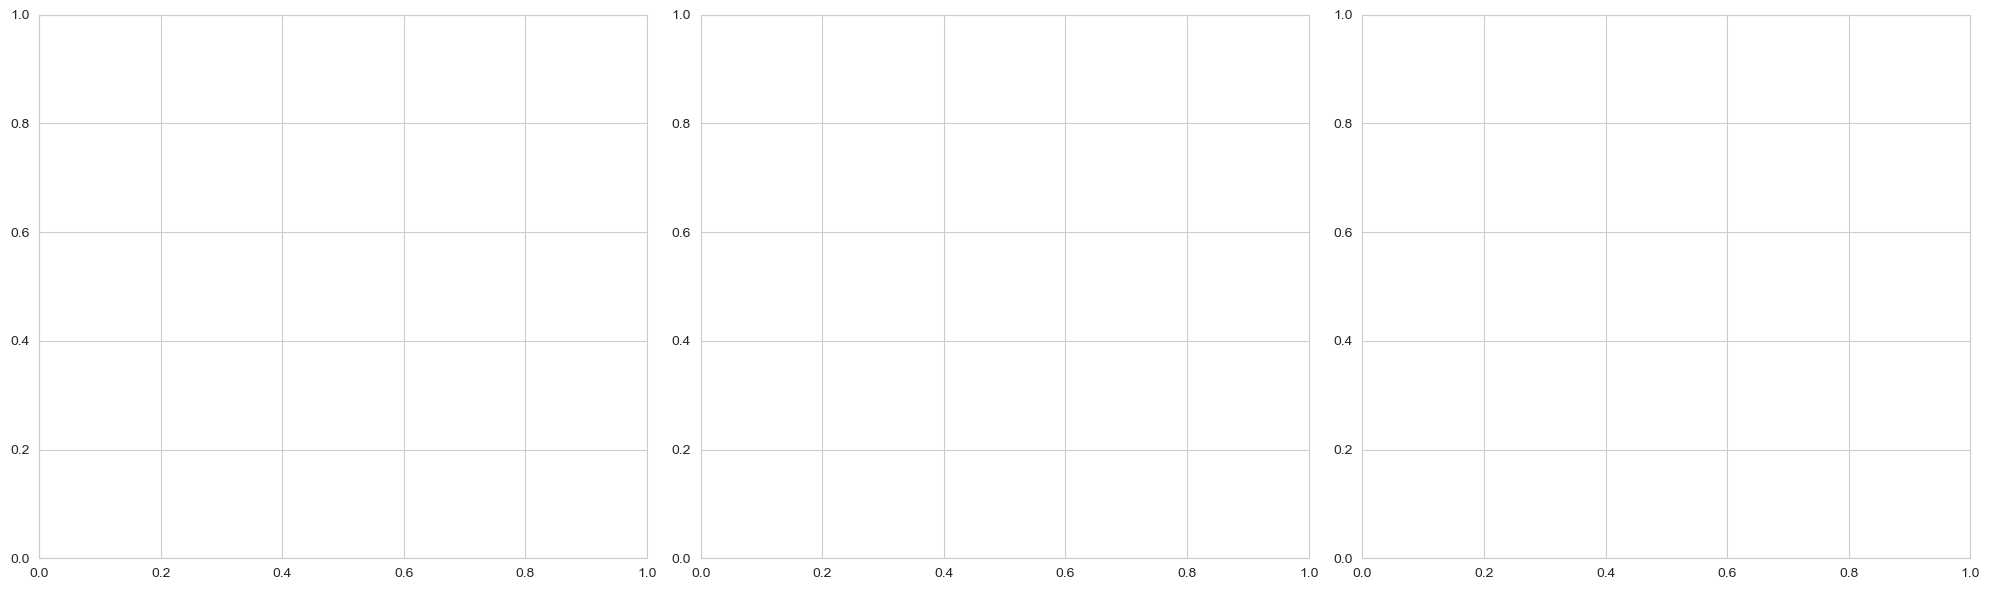

In [ ]:
# Define colors for each ksize
ksizes = sorted(hp_filtered["ksize"].unique().to_list())
colors = sns.color_palette("viridis", len(ksizes))
ksize_colors = dict(zip(ksizes, colors))

# Define the hierarchical levels to plot
# Column names will be adjusted based on actual data
levels = {
    "Family": "family_rank",
    "Superfamily": "superfamily_rank",
    "Fold": "fold_rank",
}

# Create figure with 3 subplots (one for each hierarchical level)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (level_name, level_col) in zip(axes, levels.items()):
    # Check if column exists
    if level_col not in hp_filtered.columns:
        print(
            f"Warning: Column {level_col} not found. Available columns: {hp_filtered.columns}"
        )
        continue

    # Calculate sensitivity for this level
    sensitivity_data = calculate_sensitivity(hp_filtered, level_col, has_ksize=True)

    # Plot each ksize
    for ksize in ksizes:
        ksize_data = sensitivity_data.filter(pl.col("ksize") == ksize)

        # Get unique rank values and corresponding fraction of queries
        # This is the sensitivity at each rank threshold
        plot_data = ksize_data.select([level_col, "fraction_of_queries"]).unique()
        plot_df = plot_data.to_pandas()

        ax.plot(
            plot_df["fraction_of_queries"],
            plot_df[level_col],
            label=f"HP k={ksize}",
            color=ksize_colors[ksize],
            linewidth=2,
        )

    ax.set_xlabel("Fraction of queries", fontsize=12)
    ax.set_ylabel("Sensitivity up to the 1st FP", fontsize=12)
    ax.set_title(level_name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hp_k15_k20_sensitivity_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Compare with TEA baseline

Now let's add TEA results for comparison.

In [ ]:
# Load TEA results from the rocx files directory
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

# List TEA CSV files
tea_files = sorted(tea_dir.glob("*.csv"))
if not tea_files:
    # Try .rocx extension
    tea_files = sorted(tea_dir.glob("*.rocx"))

print(f"Found {len(tea_files)} TEA result files in {tea_dir}")
for f in tea_files[:10]:
    file_size_gb = f.stat().st_size / (1024**3)
    print(f"  {f.name} ({file_size_gb:.2f} GB)")

Found 10 TEA result files in /Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files
  3Di_exact.rocx (0.00 GB)
  3Di_sensitive.rocx (0.00 GB)
  eba.rocx (0.00 GB)
  foldseek.rocx (0.00 GB)
  mmseqs.rocx (0.00 GB)
  tea_all.rocx (0.00 GB)
  tea_fold_1.rocx (0.00 GB)
  tea_fold_2.rocx (0.00 GB)
  tea_fold_3.rocx (0.00 GB)
  tea_fold_4.rocx (0.00 GB)


NameError: name 'tea_data' is not defined

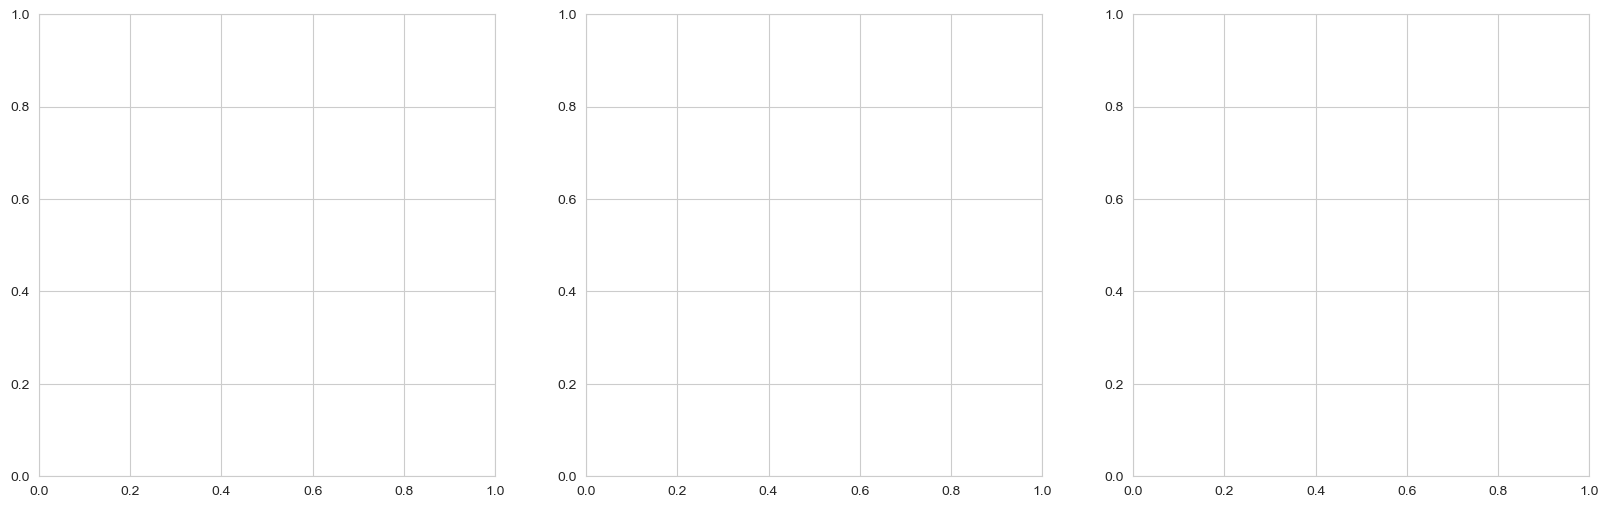

In [ ]:
# Create figure with TEA comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Determine metric column for TEA (might be different)
tea_metric_col = (
    "tfidf" if tea_data is not None and "tfidf" in tea_data.columns else metric_col
)

for ax, (level_name, level_match_col) in zip(axes, levels.items()):
    print(f"Calculating sensitivity for {level_name} with TEA comparison...")

    # Plot HP results for each ksize
    for ksize in ksizes:
        ksize_data = hp_filtered.filter(pl.col("ksize") == ksize)

        sensitivity_df = calculate_sensitivity_to_first_fp(
            ksize_data, metric_col, level_match_col, has_ksize=False
        )

        sensitivity_df = sensitivity_df.sort("sensitivity_to_first_fp")
        total_queries = sensitivity_df.shape[0]
        plot_df = sensitivity_df.with_columns(
            [
                (pl.arange(0, total_queries) + 1 / total_queries).alias(
                    "fraction_of_queries"
                )
            ]
        ).to_pandas()

        ax.plot(
            plot_df["fraction_of_queries"],
            plot_df["sensitivity_to_first_fp"],
            label=f"HP k={ksize}",
            color=ksize_colors[ksize],
            linewidth=2,
        )

    # Plot TEA baseline if available
    if tea_data is not None and level_match_col in tea_data.columns:
        tea_sensitivity_df = calculate_sensitivity_to_first_fp(
            tea_data, tea_metric_col, level_match_col, has_ksize=False
        )

        tea_sensitivity_df = tea_sensitivity_df.sort("sensitivity_to_first_fp")
        total_tea_queries = tea_sensitivity_df.shape[0]
        tea_plot_df = tea_sensitivity_df.with_columns(
            [
                (pl.arange(0, total_tea_queries) + 1 / total_tea_queries).alias(
                    "fraction_of_queries"
                )
            ]
        ).to_pandas()

        ax.plot(
            tea_plot_df["fraction_of_queries"],
            tea_plot_df["sensitivity_to_first_fp"],
            label="TEA",
            color="purple",
            linewidth=2.5,
            linestyle="--",
        )

    ax.set_xlabel("Fraction of queries", fontsize=12)
    ax.set_ylabel("Sensitivity up to the 1st FP", fontsize=12)
    ax.set_title(level_name, fontsize=14, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hp_k15_k20_vs_tea_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Add hierarchical levels to TEA data if loaded
if tea_data is not None:
    print("Adding hierarchical levels to TEA data...")
    tea_data = add_hierarchical_levels(tea_data)
    print(f"TEA data shape after adding levels: {tea_data.shape}")
    tea_data.head(10)

In [ ]:
# Generate plots for each metric
metrics = {
    "TF-IDF": "tfidf",
    "Max Containment": "max_containment",
    "Jaccard": "jaccard",
}

for metric_name, metric_col in metrics.items():
    print(f"\nGenerating plot for {metric_name}...")
    if metric_col in hp_filtered.columns:
        plot_metric_comparison(
            hp_filtered, tea_data, metric_col, metric_name, levels, ksizes, ksize_colors
        )
    else:
        print(f"  Column {metric_col} not found in HP data. Available columns:")
        print(f"  {hp_filtered.columns}")

In [ ]:
def plot_metric_comparison(
    hp_data, tea_data, metric_col, metric_name, levels, ksizes, ksize_colors
):
    """
    Create a 1x3 figure comparing HP ksizes vs TEA for a specific metric.
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Determine TEA metric column
    tea_metric_col = (
        metric_col
        if tea_data is not None and metric_col in tea_data.columns
        else "tfidf"
    )

    for ax, (level_name, level_match_col) in zip(axes, levels.items()):
        print(f"  {level_name}...", end=" ")

        # Plot HP results for each ksize
        for ksize in ksizes:
            ksize_data = hp_data.filter(pl.col("ksize") == ksize)

            sensitivity_df = calculate_sensitivity_to_first_fp(
                ksize_data, metric_col, level_match_col, has_ksize=False
            )

            sensitivity_df = sensitivity_df.sort("sensitivity_to_first_fp")
            total_queries = sensitivity_df.shape[0]
            plot_df = sensitivity_df.with_columns(
                [
                    ((pl.arange(0, total_queries) + 1) / total_queries).alias(
                        "fraction_of_queries"
                    )
                ]
            ).to_pandas()

            ax.plot(
                plot_df["fraction_of_queries"],
                plot_df["sensitivity_to_first_fp"],
                label=f"HP k={ksize}",
                color=ksize_colors[ksize],
                linewidth=2,
            )

        # Plot TEA baseline if available
        if tea_data is not None and level_match_col in tea_data.columns:
            tea_sensitivity_df = calculate_sensitivity_to_first_fp(
                tea_data, tea_metric_col, level_match_col, has_ksize=False
            )

            tea_sensitivity_df = tea_sensitivity_df.sort("sensitivity_to_first_fp")
            total_tea_queries = tea_sensitivity_df.shape[0]
            tea_plot_df = tea_sensitivity_df.with_columns(
                [
                    ((pl.arange(0, total_tea_queries) + 1) / total_tea_queries).alias(
                        "fraction_of_queries"
                    )
                ]
            ).to_pandas()

            ax.plot(
                tea_plot_df["fraction_of_queries"],
                tea_plot_df["sensitivity_to_first_fp"],
                label="TEA",
                color="purple",
                linewidth=2.5,
                linestyle="--",
            )

        ax.set_xlabel("Fraction of queries", fontsize=12)
        ax.set_ylabel("Sensitivity up to the 1st FP", fontsize=12)
        ax.set_title(level_name, fontsize=14, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="best", fontsize=10)
        ax.grid(True, alpha=0.3)

    print("Done!")
    fig.suptitle(
        f"{metric_name} Comparison: HP k15-k20 vs TEA",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    # Save figure
    filename = f'hp_k15_k20_vs_tea_{metric_name.lower().replace(" ", "_").replace("-", "_")}.pdf'
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()

    return fig

## Summary of Results

This section provides comparison plots for different metrics (TF-IDF, Max Containment, Jaccard) across hierarchical levels.

In [ ]:
# Generate plots for each metric
# First, we need to determine the actual column names from the data

# Check if we have the metric columns
for metric_name, metric_col in metrics.items():
    print(f"\nGenerating plot for {metric_name}...")
    if metric_col in hp_filtered.columns:
        plot_metric_comparison(
            hp_filtered, tea_data, metric_col, metric_name, levels, ksizes, ksize_colors
        )
    else:
        print(f"Column {metric_col} not found in data. Available columns:")
        print(hp_filtered.columns)

In [ ]:
def plot_metric_comparison(
    hp_data, tea_data, metric_col, metric_name, levels, ksizes, ksize_colors
):
    """
    Create a 1x3 figure comparing HP ksizes vs TEA for a specific metric.

    Parameters:
    -----------
    hp_data : polars.DataFrame
        HP results with ksize column
    tea_data : polars.DataFrame or None
        TEA results
    metric_col : str
        Column name for the metric (e.g., 'tf_idf_rank')
    metric_name : str
        Display name for the metric (e.g., 'TF-IDF')
    levels : dict
        Dictionary mapping level names to column names
    ksizes : list
        List of ksizes to plot
    ksize_colors : dict
        Dictionary mapping ksizes to colors
    """
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    for ax, (level_name, level_col) in zip(axes, levels.items()):
        if level_col not in hp_data.columns:
            print(f"Warning: Column {level_col} not found. Skipping {level_name}.")
            continue

        # Plot HP results for each ksize
        sensitivity_data = calculate_sensitivity(hp_data, level_col, has_ksize=True)

        for ksize in ksizes:
            ksize_data = sensitivity_data.filter(pl.col("ksize") == ksize)
            plot_data = ksize_data.select([level_col, "fraction_of_queries"]).unique()
            plot_df = plot_data.to_pandas()

            ax.plot(
                plot_df["fraction_of_queries"],
                plot_df[level_col],
                label=f"HP k={ksize}",
                color=ksize_colors[ksize],
                linewidth=2,
            )

        # Plot TEA baseline if available
        if tea_data is not None and level_col in tea_data.columns:
            tea_sensitivity = calculate_sensitivity(
                tea_data, level_col, has_ksize=False
            )
            tea_plot_data = tea_sensitivity.select(
                [level_col, "fraction_of_queries"]
            ).unique()
            tea_plot_df = tea_plot_data.to_pandas()

            ax.plot(
                tea_plot_df["fraction_of_queries"],
                tea_plot_df[level_col],
                label="TEA",
                color="purple",
                linewidth=2.5,
                linestyle="--",
            )

        ax.set_xlabel("Fraction of queries", fontsize=12)
        ax.set_ylabel("Sensitivity up to the 1st FP", fontsize=12)
        ax.set_title(level_name, fontsize=14, fontweight="bold")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="best", fontsize=10)
        ax.grid(True, alpha=0.3)

    fig.suptitle(
        f"{metric_name} Comparison: HP k15-k20 vs TEA",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    # Save figure
    filename = f'hp_k15_k20_vs_tea_{metric_name.lower().replace(" ", "_").replace("-", "_")}.pdf'
    plt.savefig(filename, bbox_inches="tight", dpi=300)
    plt.show()

    return fig

### Plot by metric: Each metric gets 3 subplots (Family, Superfamily, Fold)

In [ ]:
# Define metrics to compare
# Common metrics in sourmash/kmerseek: tf-idf (average_kmer_rarity), max_containment, jaccard
metrics = {
    "TF-IDF": "tf_idf_rank",  # or 'average_kmer_rarity_rank'
    "Max Containment": "max_containment_rank",
    "Jaccard": "jaccard_rank",
}

# We'll need to identify the correct column names from the data
# They might be named differently